In [2]:
import os
import json
import pickle
import warnings
import numpy as np
import xarray as xr
import proplot as pplt
warnings.filterwarnings('ignore')
pplt.rc.update({
    'savefig.dpi':900,
    'savefig.bbox':'tight',
    'savefig.pad_inches':0.02,
    'tick.minor':False,
    'font.size':9,
    'label.size':9,
    'tick.labelsize':9,
    'title.size':9,
    'abc.size':9,
    'legend.fontsize':9,
    'suptitle.size':9,
    'leftlabelsize':9,
    'toplabelsize':9,
    'leftlabel.weight':'normal',
    'toplabel.weight':'normal',
    'reso':'xx-hi'})

In [3]:
with open('../scripts/configs.json','r',encoding='utf-8') as f:
    CONFIGS = json.load(f)
SPLITSDIR  = CONFIGS['filepaths']['splits']
WEIGHTSDIR = CONFIGS['filepaths']['weights']
MODELSDIR  = CONFIGS['filepaths']['models']
MODELS     = CONFIGS['experiments']
SPLIT      = 'test'

SR_GAUSS_FIELDVARS = MODELS['sr']['runs']['sr_gauss']['fieldvars']
NN_SEEDS           = MODELS['nn']['seeds']

COLORS = {}
LABELS = {}
for name,cfg in MODELS['sr']['optimizedeqs'].items():
    COLORS[name] = cfg['color']
    LABELS[name] = cfg['description']

MINSAMP = 30
NBINS   = 40

In [11]:
SRFUNCTIONS = {
    'cube':lambda x:x**3,'square':lambda x:x**2,'neg':lambda x:-x,
    'sqrt':np.sqrt,'exp':np.exp,'log':np.log,'abs':np.abs,
    'sin':np.sin,'cos':np.cos,'max':np.maximum,'min':np.minimum}

def kernel_integrate(fields,weights,dsig,mask=None):
    w = fields * weights[None,:,:] * dsig[None,None,:]
    if mask is not None:
        w = w * mask[:,None,:]
    return w.sum(axis=2)

def to_phys(srout):
    return np.expm1(tpstd * np.maximum(0.0,np.asarray(srout,dtype=float)))

def eval_sr(name,vardict):
    if name not in SR_REGISTRY:
        return None
    entry = SR_REGISTRY[name]
    ns    = dict(SRFUNCTIONS,__builtins__={})
    ns.update(entry['constants'])
    ns.update(vardict)
    out = eval(entry['form'],ns)
    if np.ndim(out)==0:
        n   = next((len(v) for v in vardict.values() if hasattr(v,'__len__')),1)
        out = np.full(n,float(out))
    return to_phys(np.asarray(out,dtype=float))

def bin1d(x,z,nbins=NBINS,minsamp=MINSAMP,plo=1,phi=99):
    finite = np.isfinite(x) & np.isfinite(z)
    x,z    = x[finite],z[finite]
    edges  = np.unique(np.percentile(x,np.linspace(plo,phi,nbins+1)))
    n      = len(edges)-1
    xi     = np.clip(np.digitize(x,edges)-1,0,n-1)
    means  = np.full(n,np.nan); counts = np.zeros(n,int)
    for i in range(n):
        sel = xi==i; counts[i] = sel.sum()
        if counts[i]>=minsamp: means[i] = z[sel].mean()
    return edges,0.5*(edges[:-1]+edges[1:]),means,counts

def prange(arr,lo=1,hi=99):
    a = arr[np.isfinite(arr)]
    return float(np.percentile(a,lo)),float(np.percentile(a,hi))

In [13]:
with open(os.path.join(SPLITSDIR,'stats.json'),'r',encoding='utf-8') as f:
    STATS = json.load(f)
tpmean = float(STATS['tp_mean'])
tpstd  = float(STATS['tp_std'])

with xr.open_dataset(os.path.join(SPLITSDIR,f'norm_{SPLIT}.h5'),engine='h5netcdf') as ds:
    ntime = ds.sizes['time']; nlat = ds.sizes['lat']; nlon = ds.sizes['lon']
    nsig  = ds.sizes.get('sig',1)
    refshape = (ntime,nlat,nlon)
    dsig = ds['dsig'].values
    levmin,levmax = CONFIGS['domain']['levrange']
    sigcoords = (ds.coords['sig'].values if 'sig' in ds.coords
                 else np.linspace(levmin/1000,levmax/1000,nsig))
    farrs      = [ds[v].transpose('time','lat','lon','sig').values.reshape(-1,nsig)
                  for v in SR_GAUSS_FIELDVARS]
    fieldstack = np.stack(farrs,axis=1)
    surfmask   = (ds['surfmask'].transpose('time','lat','lon','sig').values.reshape(-1,nsig)
                  if 'surfmask' in ds else None)
    if 'bl' in ds:
        bl     = ds['bl']
        blnorm = (bl.mean('sig').transpose('time','lat','lon').values.ravel() if 'sig' in bl.dims
                  else bl.transpose('time','lat','lon').values.ravel())
    else:
        blnorm = None

kwlist = []
for seed in NN_SEEDS:
    wpath = os.path.join(WEIGHTSDIR,f'nn_gauss_{seed}_weights.nc')
    if os.path.exists(wpath):
        with xr.open_dataset(wpath,engine='h5netcdf') as wds:
            kwlist.append(wds['k'].values)
            if 'sig' in wds.coords and len(kwlist)==1:
                sigcoords = wds.coords['sig'].values

if kwlist:
    avgkernel   = np.mean(kwlist,axis=0)
    ki          = np.mean([kernel_integrate(fieldstack,kw,dsig,surfmask) for kw in kwlist],axis=0)
    rhk         = ki[:,0]
    thetaek     = ki[:,1]
    thetaestark = ki[:,2]
else:
    avgkernel   = None
    rhk         = fieldstack[:,0,:].mean(axis=1)
    thetaek     = fieldstack[:,1,:].mean(axis=1)
    thetaestark = fieldstack[:,2,:].mean(axis=1)

with xr.open_dataset(os.path.join(SPLITSDIR,f'{SPLIT}.h5'),engine='h5netcdf') as ds:
    trueflat = ds.tp.transpose('time','lat','lon').values.ravel()

regpath = os.path.join(MODELSDIR,'sr','optimized_equations.pkl')
if os.path.exists(regpath):
    with open(regpath,'rb') as f:
        SR_REGISTRY = pickle.load(f)
else:
    SR_REGISTRY = {}

valid = (np.isfinite(trueflat) & np.isfinite(rhk) &
         np.isfinite(thetaek) & np.isfinite(thetaestark))
print(f'Valid samples: {valid.sum():,}')

Valid samples: 1,437,408


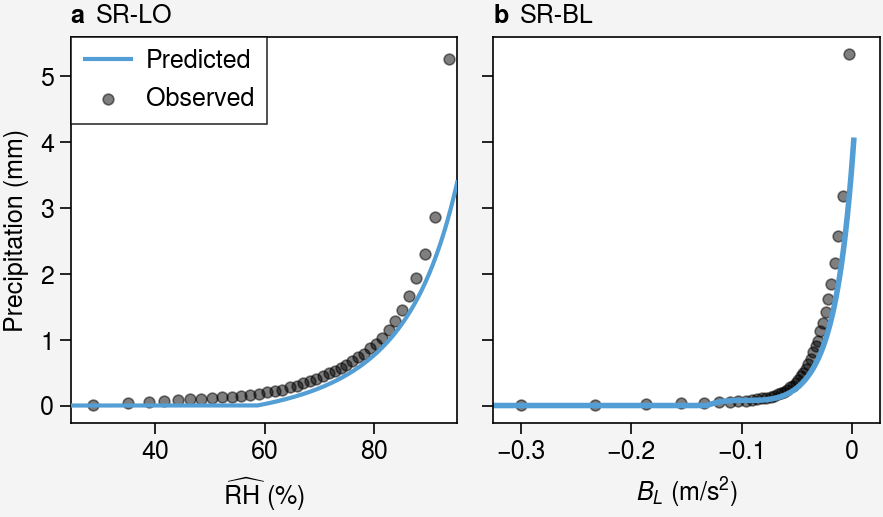

In [16]:
rhstd  = float(STATS['rh_std'])
rhmean = float(STATS['rh_mean'])
wdsig  = avgkernel[0,:]*dsig
wnorm  = wdsig/wdsig.sum()
rhnat  = ((fieldstack[:,0,:]*rhstd+rhmean)*wnorm[None,:]).sum(axis=1)
rhnatv = rhnat[valid]
rhnlo,rhnhi = prange(rhnatv)
rhnsw       = np.linspace(rhnlo,rhnhi,400)
rhnswrm     = (rhnsw-rhmean)/rhstd
Plotnat     = eval_sr('sr_lo',{'rh':rhnswrm})
_,rhncen,rhnobsmeans,_ = bin1d(rhnatv,Pv)

fig,axs = pplt.subplots(ncols=2,figwidth=4.5,sharex=False,sharey=True)
axs[0].scatter(rhncen,rhnobsmeans,color='k',alpha=0.5,s=15,zorder=0,label='Observed')
axs[0].plot(rhnsw,Plotnat,color='#539ed4',lw=1.5,zorder=5,label='Predicted')
axs[0].format(xlabel=r'$\widehat{\mathrm{RH}}$ (%)',title='SR-LO')
axs[0].legend(loc='ul',ncols=1)
axs[1].scatter(blcen,blobsmeans,color='k',alpha=0.5,s=15,zorder=0)
axs[1].plot(blswnat,Psrbl,color='#539ed4',lw=2)
axs[1].format(xlabel=r'$\mathit{B_L}$ (m/s$^2$)',xlim=(-0.325,0.025),title='SR-BL')
axs.format(grid=False,ylabel='Precipitation (mm)',titleloc='l')
fig.format(abc=True)
pplt.show()
fig.save('../figs/fig_2.jpg')